In [2]:
import sqlite3
import pandas as pd
import os
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
import kagglehub
import pandas as pd
# Download latest version
path = kagglehub.dataset_download("parsakh/global-e-commerce-and-supply-chain-database")

/usr/local/python/3.12.1/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
import sqlite3

conn = sqlite3.connect("ecommerce_supply_chain.db")
cursor = conn.cursor()

In [5]:
data_dir = "/home/codespace/.cache/kagglehub/datasets/parsakh/global-e-commerce-and-supply-chain-database/versions/1"

tables = {
    "products": "products.csv",
    "transactions": "transactions.csv",
}

for table_name, filename in tables.items():
    df = pd.read_csv(os.path.join(data_dir, filename))
    df.to_sql(table_name, conn, if_exists="append", index=False)
    print(f"Loaded {table_name}: {df.shape[0]} rows")

Loaded products: 500 rows
Loaded transactions: 100000 rows


In [6]:
conn = sqlite3.connect('ecommerce_supply_chain.db')

sql_query = """SELECT *
FROM transactions t
"""
transactions_df = pd.read_sql_query(sql_query, conn)

conn.close()

In [7]:
transactions_df.describe()

,quantity,unit_price_usd,discount_pct,revenue_usd,cost_usd,profit_usd,shipping_cost_usd
count,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000
mean,2.320440,240.483215,0.055375,528.719600,349.721733,178.997867,20.426383
std,1.920152,255.432964,0.063333,856.635246,660.950905,232.126668,29.945979
min,1.000000,8.060000,0.000000,6.450000,4.580000,-0.030000,0.000000
25%,1.000000,70.830000,0.000000,109.130000,57.460000,45.410000,0.900000
50%,2.000000,164.510000,0.050000,241.580000,133.820000,102.760000,11.040000
75%,3.000000,280.520000,0.100000,593.460000,348.360000,211.145000,24.600000
max,10.000000,1191.590000,0.250000,11915.900000,8936.900000,2979.000000,371.250000


In [8]:
conn = sqlite3.connect('ecommerce_supply_chain.db')

sql_query = """SELECT *
FROM products p
"""
products_df = pd.read_sql_query(sql_query, conn)

In [9]:
products_df.head()

,product_id,name,category,brand,unit_price_usd,unit_cost_usd,weight_kg,is_active,launch_date
0,PROD0001,CoreBrand Books Item 1,Books,BoldEdge,25.82,16.78,2.13,1,2019-11-23
1,PROD0002,PrimeLine Clothing Item 2,Clothing,ClearView,108.37,48.77,2.86,1,2021-08-14
2,PROD0003,GlowUp Home Item 3,Home & Kitchen,StyleCo,214.46,128.68,6.86,1,2019-04-09
3,PROD0004,HomePro Electronics Item 4,Electronics,PureForm,830.21,622.66,3.25,1,2019-08-28
4,PROD0005,HomePro Clothing Item 5,Clothing,ClearView,19.56,8.80,8.86,1,2020-11-18


In [10]:
sql_query = """SELECT strftime('%Y', t.date) AS year_val,
strftime('%m', t.date) AS month_val
  ,SUM(t.revenue_usd) AS total_revenue
FROM transactions t
GROUP BY year_val,month_val
"""
revenue_df = pd.read_sql_query(sql_query, conn)

In [11]:
sql_query = """SELECT 
    strftime('%Y', t.date) AS year_val,
    strftime('%m', t.date) AS month_val,
   ((SUM(cost_usd) +SUM(shipping_cost_usd)) - SUM(revenue_usd)) AS Net_Burn_Rate,
    SUM(cost_usd) +SUM(shipping_cost_usd) AS Gross_Burn_Rate
FROM transactions t
GROUP BY year_val, month_val
ORDER BY year_val DESC, month_val DESC;
"""
Net_Burn_Rate_df = pd.read_sql_query(sql_query, conn)

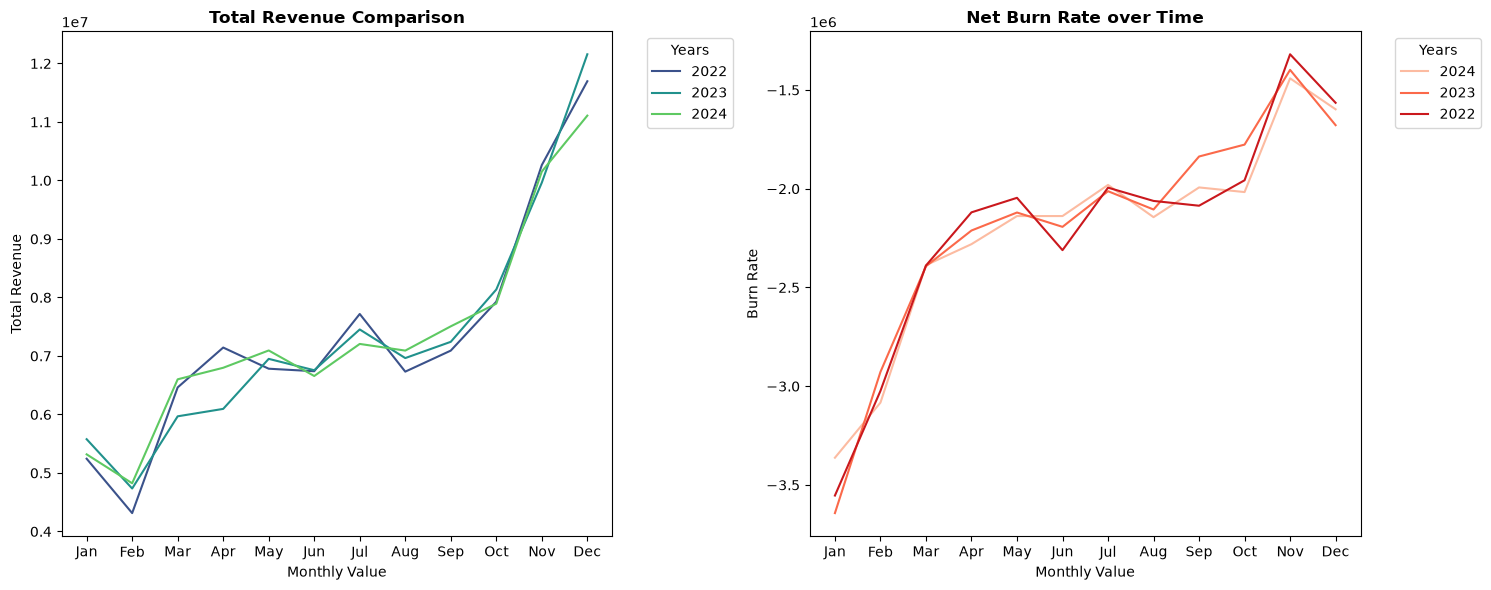

In [12]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
months_labels = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]


sns.lineplot(x='month_val', y='total_revenue', data=revenue_df, hue='year_val', palette='viridis', legend='full', ax=ax1)

ax1.set_title("Total Revenue Comparison", fontsize=12, fontweight='bold')
ax1.set_xlabel("Monthly Value")
ax1.set_ylabel("Total Revenue")

ax1.set_xticks(ticks=range(len(revenue_df["month_val"].unique())))
ax1.set_xticklabels(months_labels[:len(revenue_df["month_val"].unique())])

ax1.legend(title="Years", bbox_to_anchor=(1.05, 1), loc="upper left")



sns.lineplot(x='month_val', y='Net_Burn_Rate', data=Net_Burn_Rate_df, hue='year_val', palette='Reds', legend='full', ax=ax2)

ax2.set_title("Net Burn Rate over Time", fontsize=12, fontweight='bold')
ax2.set_xlabel("Monthly Value")
ax2.set_ylabel("Burn Rate")

ax2.set_xticks(ticks=range(len(Net_Burn_Rate_df["month_val"].unique())))
ax2.set_xticklabels(months_labels[:len(Net_Burn_Rate_df["month_val"].unique())])

ax2.legend(title="Years", bbox_to_anchor=(1.05, 1), loc="upper left")



plt.tight_layout()
plt.show()


In [13]:
sql_query = """SELECT 
    strftime('%Y', t.date) AS year_val,
    strftime('%m', t.date) AS month_val,

    SUM(revenue_usd)-(SUM(cost_usd) + SUM(shipping_cost_usd)) as Cashflow
FROM transactions t
GROUP BY year_val, month_val
ORDER BY year_val DESC, month_val ASC;
"""
Cashflow_df = pd.read_sql_query(sql_query, conn)

Text(0.5, 1.0, 'Cashflow per month')

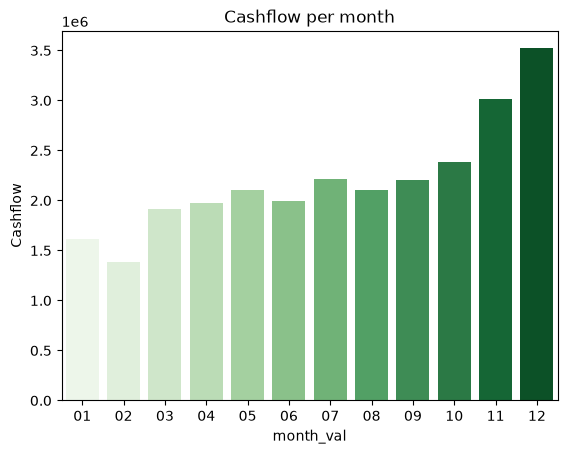

In [14]:
sns.barplot(data=Cashflow_df,x="month_val", y="Cashflow",errorbar=None,hue="month_val",palette="Greens")
plt.title("Cashflow per month")


In [15]:
sql_query = """WITH Yearly_Revenue_CTE AS (
    SELECT 
        strftime('%Y', t.date) AS year_val,
        SUM(t.revenue_usd) AS Total_Revenue
    FROM transactions t
    GROUP BY year_val
)
SELECT 
    year_val,
    Total_Revenue,
    LAG(Total_Revenue, 1) OVER (ORDER BY year_val ASC) AS Previous_Year_Revenue,
    ROUND(
        ((Total_Revenue - LAG(Total_Revenue, 1) OVER (ORDER BY year_val ASC)) 
        / LAG(Total_Revenue, 1) OVER (ORDER BY year_val ASC)) * 100, 
        2
    ) AS YoY_Growth_Percent
FROM Yearly_Revenue_CTE
ORDER BY year_val ASC;
"""
YoY_df = pd.read_sql_query(sql_query, conn)

In [16]:
YoY_df.head()

,year_val,Total_Revenue,Previous_Year_Revenue,YoY_Growth_Percent
0,2022,88113171.45,NaN,NaN
1,2023,87995784.90,88113171.45,-0.13
2,2024,88250843.85,87995784.90,0.29


In [17]:
sql_query = """
WITH Monthly_Revenue_CTE AS (
    SELECT 
        strftime('%Y', t.date) AS year_val,
        strftime('%m', t.date) AS month_val,
        SUM(t.revenue_usd) AS Total_Revenue
    FROM transactions t
    GROUP BY year_val, month_val
)
SELECT 
    year_val,
    month_val,
    Total_Revenue,
    LAG(Total_Revenue, 1) OVER (ORDER BY year_val ASC, month_val ASC) AS Previous_Month_Revenue,
    ROUND(
        ((Total_Revenue - LAG(Total_Revenue, 1) OVER (ORDER BY year_val ASC, month_val ASC)) 
        / LAG(Total_Revenue, 1) OVER (ORDER BY year_val ASC, month_val ASC)) * 100, 
        2
    ) AS MoM_Growth_Percent
FROM Monthly_Revenue_CTE
ORDER BY year_val ASC, month_val ASC;
"""
MoM_df = pd.read_sql_query(sql_query, conn)


/tmp/ipykernel_54189/1765271421.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(
/tmp/ipykernel_54189/1765271421.py:7: UserWarning: The palette list has more values (36) than needed (12), which may not be intended.
  ax = sns.barplot(


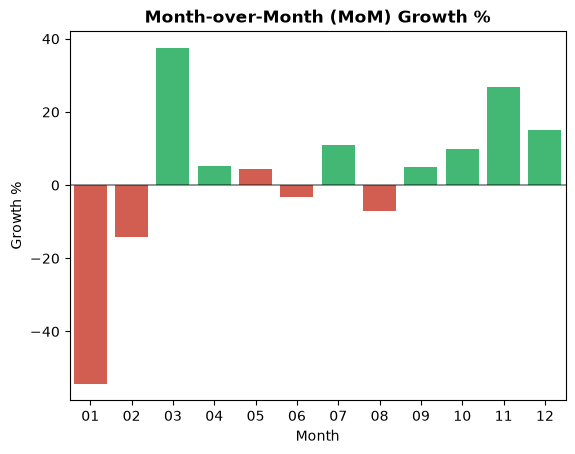

In [18]:
colors = ['#2ecc71' if x > 0 else '#e74c3c' for x in MoM_df['MoM_Growth_Percent']]

# 2. Set up the figure size
plt.figsize=(10, 5)

# 3. Pass the custom colors list into the palette argument
ax = sns.barplot(
    data=MoM_df, 
    x="month_val", 
    y="MoM_Growth_Percent", 
    palette=colors,errorbar=None
)

# 4. Add a horizontal line at 0 to make the separation visually perfect
ax.axhline(0, color='black', linestyle='-', linewidth=1.2, alpha=0.5)

# 5. Clean up labels and title
ax.set_title("Month-over-Month (MoM) Growth %", fontsize=12, fontweight='bold')
ax.set_xlabel("Month")
ax.set_ylabel("Growth %")

plt.show()

In [29]:
sql_query = """
SELECT 
    strftime('%Y', t.date) AS year_val,
    strftime('%m', t.date) AS month_val,
    p.brand as brand,
    SUM(t.revenue_usd) AS gross_revenue,
    (SUM(t.cost_usd) + SUM(t.shipping_cost_usd)) AS total_cogs,
    (SUM(t.revenue_usd) - (SUM(t.cost_usd) + SUM(t.shipping_cost_usd))) AS gross_profit
FROM transactions t
JOIN products p ON t.product_id = p.product_id
WHERE t.status = 'completed'
GROUP BY year_val, month_val, p.brand
ORDER BY year_val DESC, month_val DESC, gross_profit DESC;
"""
Profitable_Brands_df = pd.read_sql_query(sql_query, conn)

/tmp/ipykernel_54189/1515730394.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=brand_totals, x='brand', y='gross_profit', palette='viridis', ax=ax1)
/tmp/ipykernel_54189/1515730394.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=brand_totals, x='brand', y='gross_revenue', palette='magma', ax=ax2)


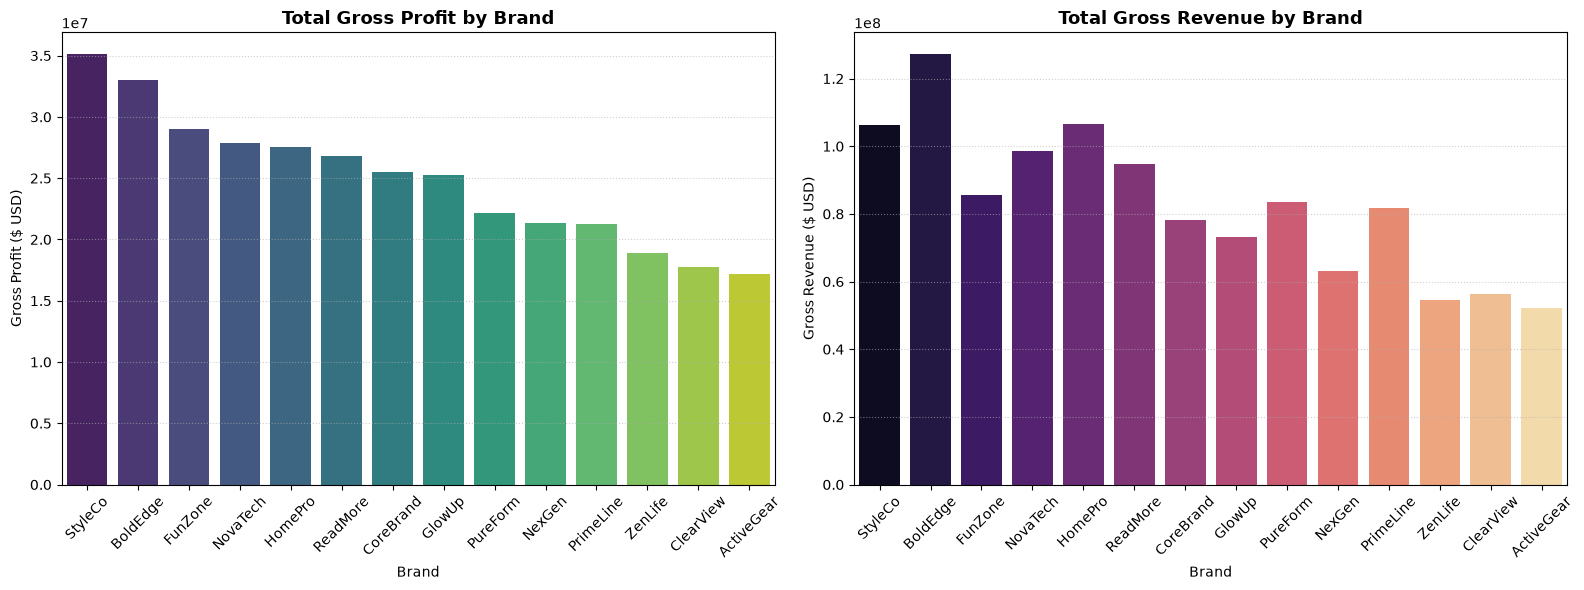

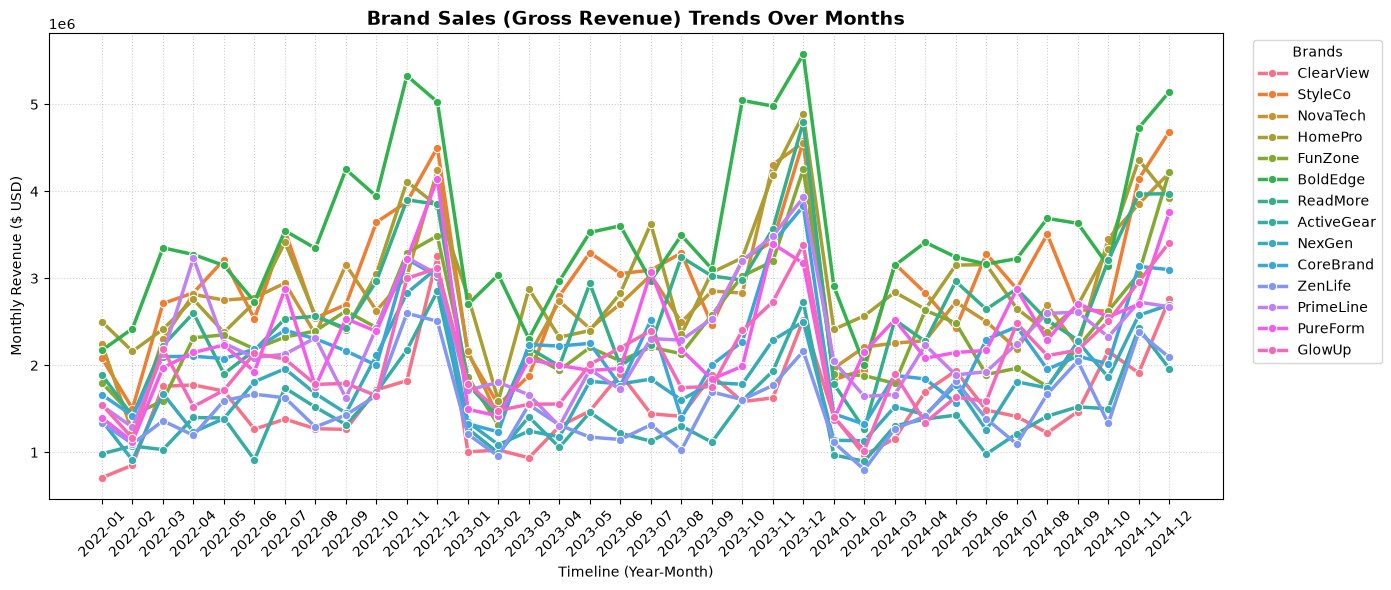

In [30]:
brand_totals = Profitable_Brands_df.groupby('brand')[['gross_revenue', 'gross_profit']].sum().reset_index()
brand_totals = brand_totals.sort_values(by='gross_profit', ascending=False)

timeline_df = Profitable_Brands_df.copy()
timeline_df['year_month'] = timeline_df['year_val'] + '-' + timeline_df['month_val']
timeline_df = timeline_df.sort_values(by='year_month')

# =====================================================================
# VISUALIZATION 1 & 2: Profit & Revenue Comparison (Side-by-Side)
# =====================================================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(data=brand_totals, x='brand', y='gross_profit', palette='viridis', ax=ax1)
ax1.set_title("Total Gross Profit by Brand", fontsize=13, fontweight='bold')
ax1.set_xlabel("Brand")
ax1.set_ylabel("Gross Profit ($ USD)")
ax1.tick_params(axis='x', rotation=45)
ax1.grid(axis='y', linestyle=':', alpha=0.6)

sns.barplot(data=brand_totals, x='brand', y='gross_revenue', palette='magma', ax=ax2)
ax2.set_title("Total Gross Revenue by Brand", fontsize=13, fontweight='bold')
ax2.set_xlabel("Brand")
ax2.set_ylabel("Gross Revenue ($ USD)")
ax2.tick_params(axis='x', rotation=45)
ax2.grid(axis='y', linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

# =====================================================================
# VISUALIZATION 3: Sales Trends Over Time by Brand
# =====================================================================
plt.figure(figsize=(14, 6))

sns.lineplot(
    data=timeline_df, 
    x='year_month', 
    y='gross_revenue', 
    hue='brand', 
    marker='o', 
    linewidth=2.5
)

plt.title("Brand Sales (Gross Revenue) Trends Over Months", fontsize=14, fontweight='bold')
plt.xlabel("Timeline (Year-Month)")
plt.ylabel("Monthly Revenue ($ USD)")
plt.xticks(rotation=45)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(title="Brands", bbox_to_anchor=(1.02, 1), loc='upper left')

plt.tight_layout()
plt.show()

In [ ]:
sql_query = """
WITH Brand_Sales AS (
    -- Step 1: Calculate total revenue for each individual brand
    SELECT 
        p.brand AS brand,
        SUM(t.revenue_usd) AS brand_revenue
    FROM transactions t
    JOIN products p ON t.product_id = p.product_id
    WHERE t.status = 'completed'
    GROUP BY p.brand
)
SELECT 
    brand,
    brand_revenue,
    -- Step 2: Divide brand revenue by the global total (calculated via window function)
    ROUND(
        (brand_revenue / SUM(brand_revenue) OVER ()) * 100, 
        2
    ) AS percentage_of_total
FROM Brand_Sales
ORDER BY brand_revenue DESC
LIMIT 3
"""

Top_3_Brands_df = pd.read_sql_query(sql_query, conn)



In [38]:
print(Top_3_Brands_df)

      brand  brand_revenue  percentage_of_total
0  BoldEdge   1.273073e+08                10.95
1   HomePro   1.066279e+08                 9.17
2   StyleCo   1.064211e+08                 9.15
